##Problem Statement

**Loan default problem:**

Loan default is a major risk for financial institutions, as approving loans to customers who are unable to repay can lead to significant financial losses. At the same time, rejecting loans for customers who are capable of repayment may result in loss of business.

The objective of this analysis is to use Exploratory Data Analysis (EDA) to understand the patterns and factors that influence loan default. By analysing customer demographic and financial attributes, the company aims to identify applicants who are likely to face payment difficulties, so that better loan approval decisions can be made.

**Business Understanding:**

When a customer applies for a loan, the company faces two types of risks. If a loan is approved for a customer who is likely to default, the company may suffer a financial loss. On the other hand, if a loan is rejected for a customer who is capable of repaying, it may lead to loss of potential business.

The dataset provided contains information about loan applicants along with a target variable that indicates whether the client had payment difficulties. Using EDA, the goal is to understand how different customer and loan attributes are related to loan default. These insights can help the company reduce risk by adjusting loan approval policies, loan amounts, or interest rates.

**EDA Purpose:**

The purpose of performing Exploratory Data Analysis is to identify key driver variables that differentiate defaulters from non-defaulters. This analysis focuses on handling missing values, identifying outliers, analysing data imbalance, and understanding relationships between variables using univariate, bivariate, and correlation analysis. The insights derived will support data-driven decision-making in credit risk assessment.

##Data Understanding

**Data Overview:**

The data provided for this case study consists of three datasets. The primary dataset, application_data.csv, contains information about loan applicants at the time of application, including demographic details, financial information, and a target variable indicating whether the client faced payment difficulties.

The second dataset, previous_application.csv, contains historical loan application details of the clients, such as the status of previous loan applications. The third dataset, columns_description.csv, serves as a data dictionary and provides descriptions for all the variables present in the datasets.

For this analysis, the application_data dataset is used as the main dataset since it contains the target variable required to analyse loan default behaviour.


In [1]:
#Import Required Libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings:
pd.set_option('display.max_columns', None)

In [2]:
#Load the Datasets:
application_df = pd.read_csv('application_data.csv', low_memory=False)
previous_df = pd.read_csv('previous_application.csv', low_memory=False)
columns_desc = pd.read_csv('columns_description.csv', encoding='latin1')

In [3]:
#Dataset Dimensions:
application_df.shape, previous_df.shape, columns_desc.shape

((307511, 122), (1670214, 37), (160, 5))

In [4]:
#Dataset Structure:
application_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


##Data Structure Explanation




The application_data dataset consists of a large number of observations, where each row represents a loan application and each column represents a specific attribute related to the client or the loan. The dataset includes both numerical and categorical variables such as income, loan amount, education level, and employment details.

The presence of different data types indicates that appropriate preprocessing steps such as missing value treatment and encoding will be required before further analysis.

**Understanding the Target Variable:**

In [5]:
application_df['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [6]:
application_df['TARGET'].value_counts(normalize=True) * 100

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

**Target Variable Explanation:**

The target variable in the dataset is 'TARGET'. A value of 1 indicates that the client had payment difficulties, meaning the client defaulted or had delayed payments. A value of 0 indicates that the client did not face any payment difficulties and paid the loan on time.

This target variable is used to distinguish between defaulters and non-defaulters and will be the primary focus of the analysis.


In [7]:
#Preview of the Dataset:
application_df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

##Data Imbalance Analysis

**Target Variable Distribution:**

Before performing further analysis, it is important to check whether the dataset is balanced or imbalanced with respect to the target variable. In loan default problems, it is common to observe fewer defaulters compared to non-defaulters.

An imbalanced dataset can bias the analysis if only absolute counts are considered. Hence, both absolute numbers and percentage distribution of the target variable are analysed.


**Count of Target Variable:**

In [8]:
application_df['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

**Percentage Distribution of Target Variable:**

In [9]:
application_df['TARGET'].value_counts(normalize=True) * 100

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

**Visualization of Target Variable:**

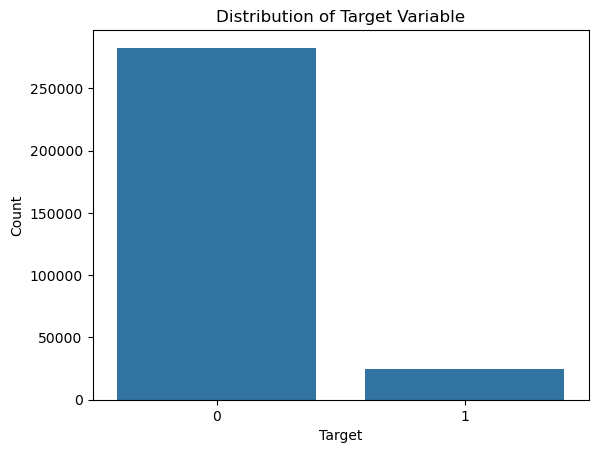

In [10]:
sns.countplot(x='TARGET', data=application_df)
plt.title('Distribution of Target Variable')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

**Imbalance Explanation:**

The above analysis shows that the dataset is highly imbalanced. The majority of loan applicants belong to the non-defaulter category (TARGET = 0), while only a small percentage of applicants have payment difficulties (TARGET = 1).

Due to this imbalance, analysing the data only using absolute counts may lead to misleading conclusions. Therefore, percentage-based analysis and segmented analysis are used in the subsequent sections to better understand the characteristics of defaulters and non-defaulters.


##Missing Value Analysis

Missing values are a common issue in real-world datasets, especially in financial and loan-related data. Handling missing values appropriately is crucial, as improper treatment may lead to biased analysis and incorrect conclusions.

In this section, the percentage of missing values in each variable is analysed to decide whether the variable should be removed or imputed using an appropriate method.


**Percentage of Missing Values per Column:**

In [11]:
missing_percentage = application_df.isnull().mean() * 100
missing_percentage = missing_percentage.sort_values(ascending=False)
missing_percentage.head(20)

COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
FLOORSMIN_MODE              67.848630
FLOORSMIN_AVG               67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_AVG             66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_MEDI            66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_AVG                59.376738
LANDAREA_MODE               59.376738
dtype: float64

**Missing Value Summary:**

From the above analysis, it can be observed that several variables have a very high percentage of missing values. Variables with extremely high missing values may not provide meaningful insights and can introduce noise into the analysis.

Hence, columns with more than 40% missing values are considered for removal from the dataset.


**Dropping Columns with High Missing Values (>40%):**

In [12]:
missing_threshold = 40
cols_to_drop = missing_percentage[missing_percentage > missing_threshold].index
application_df = application_df.drop(columns=cols_to_drop)

application_df.shape

(307511, 73)

**Missing Value Treatment Strategy:**

After removing columns with high missing values, the remaining missing values are handled using appropriate imputation techniques.

For numerical variables, missing values are replaced with the median of the respective column. Median is preferred over mean because the data contains outliers and is often skewed.

For categorical variables, missing values are replaced with the mode (most frequent category), as it best represents the most common category in the data.


**Imputing Missing Values:**

In [13]:
# Separate numerical and categorical columns
numerical_cols = application_df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = application_df.select_dtypes(include=['object']).columns

# Impute numerical columns with median
for col in numerical_cols:
    application_df[col].fillna(application_df[col].median(), inplace=True)

# Impute categorical columns with mode
for col in categorical_cols:
    application_df[col].fillna(application_df[col].mode()[0], inplace=True)

C:\Users\patil\AppData\Local\Temp\ipykernel_4892\2938529448.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  application_df[col].fillna(application_df[col].median(), inplace=True)
C:\Users\patil\AppData\Local\Temp\ipykernel_4892\2938529448.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behave

**Final Check for Missing Values:**

In [14]:
application_df.isnull().sum().sum()

np.int64(0)

**Conclusion on Missing Values:**

After the missing value treatment, the dataset no longer contains any missing values. The chosen approach ensures that important information is retained while minimising the impact of missing data on the analysis.

This cleaned dataset is now suitable for further exploratory data analysis.


##Outlier Analysis

Outliers are extreme values that differ significantly from other observations in the dataset. In financial datasets, outliers are quite common and may represent genuine cases such as very high income customers or large loan amounts.

Identifying outliers helps in understanding the spread and variability of the data. However, for this analysis, outliers are not removed, as they may carry important business information.


**Selecting Key Numerical Variables:**

For outlier analysis, key numerical variables related to customer income and loan amount are selected. These variables play an important role in understanding the financial profile of the applicants.


**Outlier Analysis - Income:**

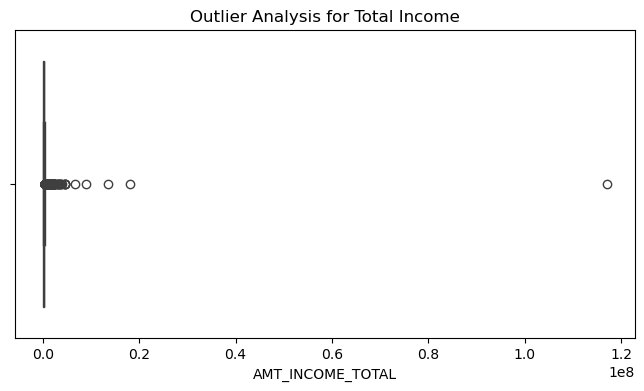

In [15]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=application_df['AMT_INCOME_TOTAL'])
plt.title('Outlier Analysis for Total Income')
plt.show()

**Outlier Analysis - Credit Amount:**

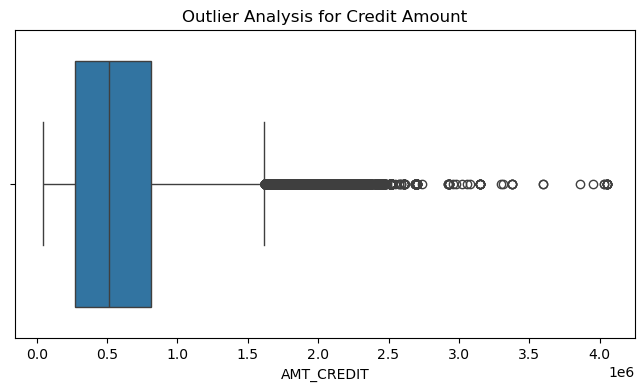

In [16]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=application_df['AMT_CREDIT'])
plt.title('Outlier Analysis for Credit Amount')
plt.show()

**Outlier Analysis - Annuity Amount:**

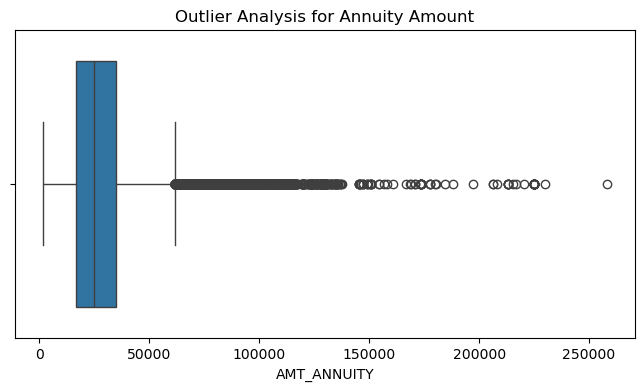

In [17]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=application_df['AMT_ANNUITY'])
plt.title('Outlier Analysis for Annuity Amount')
plt.show()

**Outlier Interpretation:**

From the boxplots above, it can be observed that the variables such as total income, credit amount, and annuity amount contain several outliers. These outliers represent applicants with very high income levels or large loan amounts.

Such values are expected in real-world financial data and may correspond to high-value customers. Therefore, these outliers are not removed from the dataset, as doing so may lead to loss of valuable information and biased analysis.


**Conclusion on Outliers:**

The presence of outliers in key financial variables highlights the diverse financial profiles of loan applicants. Since these outliers are meaningful and realistic, they are retained for further analysis.


##Univariate Analysis

Univariate analysis involves analysing individual variables independently to understand their distribution, central tendency, and overall pattern. This helps in gaining insights into the characteristics of loan applicants before comparing defaulters and non-defaulters.

In this section, both numerical and categorical variables are analysed separately using appropriate visualisations.


**Total Income Distribution:**

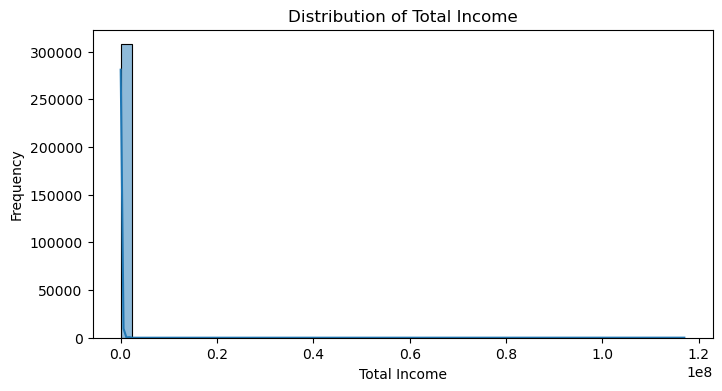

In [18]:
plt.figure(figsize=(8, 4))
sns.histplot(application_df['AMT_INCOME_TOTAL'], bins=50, kde=True)
plt.title('Distribution of Total Income')
plt.xlabel('Total Income')
plt.ylabel('Frequency')
plt.show()

**Explanation:**

The distribution of total income is right-skewed, indicating that most applicants fall within a lower income range, while a small number of applicants have very high income levels. This is typical in financial datasets and highlights income disparity among loan applicants.


**Credit Amount Distribution:**

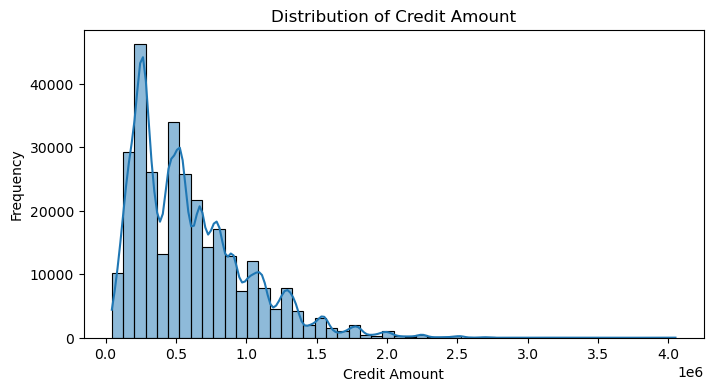

In [19]:
plt.figure(figsize=(8, 4))
sns.histplot(application_df['AMT_CREDIT'], bins=50, kde=True)
plt.title('Distribution of Credit Amount')
plt.xlabel('Credit Amount')
plt.ylabel('Frequency')
plt.show()

**Explanation:**

The credit amount distribution shows a wide spread, with most loans concentrated in the lower to mid credit range. A few applicants have taken very large loans, contributing to the skewness in the distribution.


**Annuity Amount Distribution:**

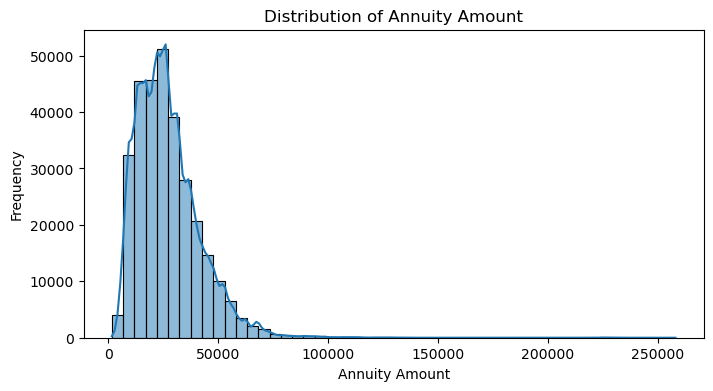

In [20]:
plt.figure(figsize=(8, 4))
sns.histplot(application_df['AMT_ANNUITY'], bins=50, kde=True)
plt.title('Distribution of Annuity Amount')
plt.xlabel('Annuity Amount')
plt.ylabel('Frequency')
plt.show()

**Explanation:**

The annuity amount is also right-skewed, indicating that most applicants have relatively smaller monthly repayment obligations, while a few applicants have significantly higher annuity amounts.


**Education Type:**

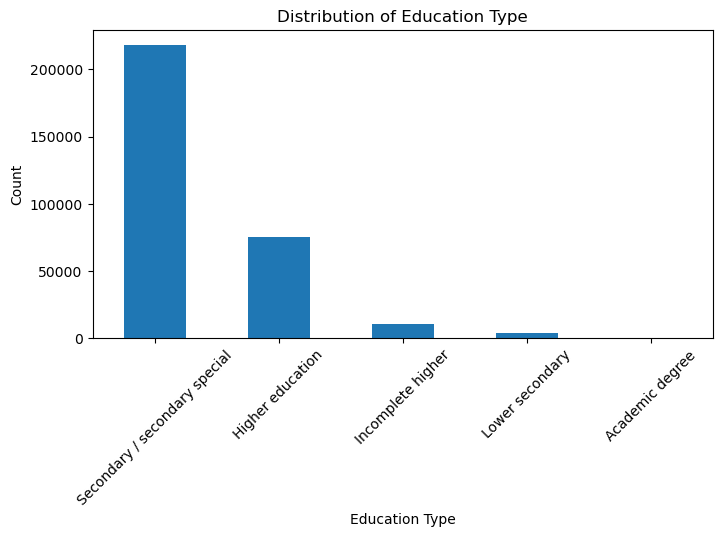

In [21]:
plt.figure(figsize=(8, 4))
application_df['NAME_EDUCATION_TYPE'].value_counts().plot(kind='bar')
plt.title('Distribution of Education Type')
plt.xlabel('Education Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

**Explanation:**

Most loan applicants belong to the Secondary / Secondary Special education category, followed by Higher Education. This indicates that the majority of the customer base consists of individuals with moderate education levels.


**Gender Distribution:**

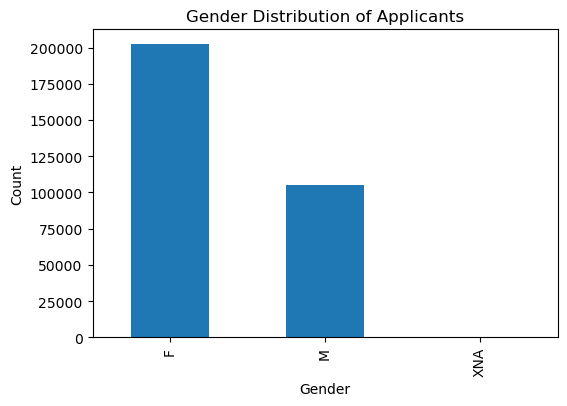

In [22]:
plt.figure(figsize=(6, 4))
application_df['CODE_GENDER'].value_counts().plot(kind='bar')
plt.title('Gender Distribution of Applicants')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

**Explanation:**

The dataset shows a higher number of female applicants compared to male applicants. Gender distribution helps in understanding the demographic composition of the applicant pool.


**Conclusion of Univariate Analysis:**

Univariate analysis provides an overview of the distribution and characteristics of individual variables. Numerical variables such as income, credit amount, and annuity show right-skewed distributions, while categorical variables such as education and gender highlight the dominant applicant groups.

These insights form the basis for further segmented and bivariate analysis to understand how these variables relate to loan default.



##Segmented Univariate Analysis

**What is Segmented Univariate Analysis?**

Segmented univariate analysis is the process of analysing a single variable across different segments or categories of another variable. Instead of studying the overall distribution, the data is divided into meaningful groups to understand how the variable behaves for each segment separately. This helps in identifying patterns, variations, and differences across groups which may not be visible in overall analysis.

In [23]:
#Import Required Libraries:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
#Load the Dataset:
df = pd.read_csv('application_data.csv')
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

**Choose Variables for Segmentation:**

For performing segmented univariate analysis, a numerical variable is analysed across different categories of a categorical variable. In this analysis, the numerical variable represents the distribution to be studied, while the categorical variable is used to create meaningful segments.

**Check Unique Segments:**

In [25]:
cat_col = 'NAME_INCOME_TYPE'
num_col = 'AMT_INCOME_TOTAL'

print("Categorical column:", cat_col)
print("Numeric column:", num_col)

print(df[cat_col].value_counts())
print(df.groupby(cat_col)[num_col].describe())


Categorical column: NAME_INCOME_TYPE
Numeric column: AMT_INCOME_TOTAL
NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64
                         count           mean            std       min  \
NAME_INCOME_TYPE                                                         
Businessman               10.0  652500.000000  627226.035812  180000.0   
Commercial associate   71617.0  202955.327289  147974.151536   26550.0   
Maternity leave            5.0  140400.000000  126856.907577   49500.0   
Pensioner              55362.0  136401.292273   76650.331247   25650.0   
State servant          21703.0  179737.969506  100880.579748   27000.0   
Student                   18.0  170500.000000  106644.682171   81000.0   
Unemployed                22.0  110536.363636  

**Interpretation of the Box Plot:**

From the box plot, it can be observed that the distribution of salary varies across different departments. Some departments show a higher median salary while others have a wider spread, indicating greater variability. The presence of outliers in certain segments suggests extreme salary values within those departments. This segmented analysis highlights differences that are not visible when analysing salary as a whole.

**Why Segmented Analysis is Important:**

Segmented univariate analysis helps in understanding how a numerical variable behaves across different groups. It enables better comparison, highlights inequalities or variations among segments, and supports more informed decision-making. Such analysis is especially useful in business and data-driven environments where group-level insights are crucial.

##Bivariate Analysis

Bivariate analysis helps in understanding the relationship between two variables. In this case study, we analyse how different customer attributes (categorical and numerical) vary across the target variable (TARGET). This helps in identifying driver variables that differentiate defaulters (TARGET = 1) from non-defaulters (TARGET = 0).

**Categorical Variable Selected:**

For this analysis, NAME_INCOME_TYPE is selected as a categorical variable to study how default rates differ across income types.

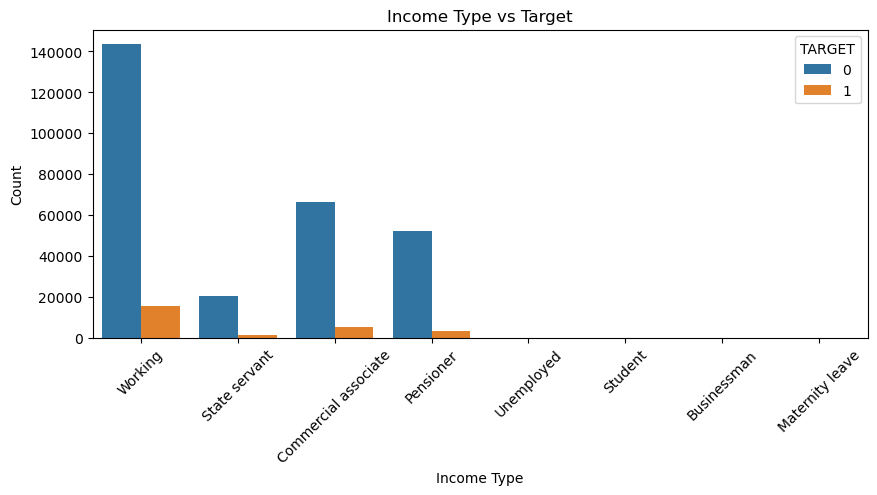

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))
sns.countplot(x='NAME_INCOME_TYPE', hue='TARGET', data=df)
plt.title('Income Type vs Target')
plt.xlabel('Income Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [27]:
default_rate = pd.crosstab(df['NAME_INCOME_TYPE'], df['TARGET'], normalize='index') * 100
default_rate

TARGET,0,1
NAME_INCOME_TYPE,,
Businessman,100.000000,0.000000
Commercial associate,92.515743,7.484257
Maternity leave,60.000000,40.000000
Pensioner,94.613634,5.386366
State servant,94.245035,5.754965
Student,100.000000,0.000000
Unemployed,63.636364,36.363636
Working,90.411528,9.588472


**Interpretation:**

Income types show different patterns of loan default. Categories with a higher proportion of TARGET = 1 indicate higher risk applicant groups. This information can be used by the company to apply stricter approval criteria or adjust interest rates for risky segments.

**Numerical Variable Selected:**

For this analysis, AMT_INCOME_TOTAL is selected as a numerical variable to study how income distribution differs for defaulters vs non-defaulters.

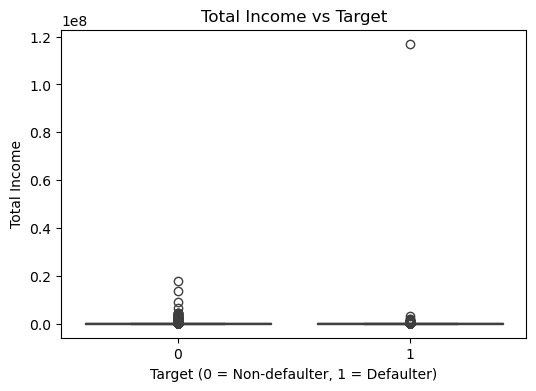

In [28]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='TARGET', y='AMT_INCOME_TOTAL', data=df)
plt.title('Total Income vs Target')
plt.xlabel('Target (0 = Non-defaulter, 1 = Defaulter)')
plt.ylabel('Total Income')
plt.show()

In [29]:
df.groupby('TARGET')['AMT_INCOME_TOTAL'].describe()

,count,mean,std,min,25%,50%,75%,max
TARGET,,,,,,,,
0,282686.0,169077.722266,110476.268524,25650.0,112500.0,148500.0,202500.0,18000090.0
1,24825.0,165611.760906,746676.959440,25650.0,112500.0,135000.0,202500.0,117000000.0


**Interpretation:**


If the median income for TARGET = 1 is lower compared to TARGET = 0, it indicates that low-income applicants have a higher likelihood of default. This suggests that income level is an important driver variable and should be considered in risk assessment.

**Conclusion:**

Bivariate analysis reveals how both categorical and numerical variables relate to loan default behaviour. Variables showing significant differences between defaulters and non-defaulters can be considered strong indicators of default risk and can support better lending decisions.

##Correlation Analysis

Correlation analysis is used to measure the strength and direction of the relationship between numerical variables. In this case study, correlation analysis helps in identifying variables that move together and may act as strong indicators of loan default behaviour. The target variable is excluded from the correlation calculation as it is categorical in nature.

**Selecting Numerical Variables:**

In [30]:
# Select only numerical columns
num_df = df.select_dtypes(include=['int64', 'float64'])
num_df.head()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,1.0,2,2,10,0,0,0,0,0,0,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,0.0149,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,0,270000.0,1293502.5,35698.5,1129500.0,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,2.0,1,1,11,0,0,0,0,0,0,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,0.0714,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,0,67500.0,135000.0,6750.0,135000.0,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,1.0,2,2,9,0,0,0,0,0,0,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-815.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,0,135000.0,312682.5,29686.5,297000.0,0.008019,-19005,-3039,-9833.0,-2437,NaN,1,1,0,1,0,0,2.0,2,2,17,0,0,0,0,0,0,NaN,0.650442,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,2.0,0.0,-617.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,0,121500.0,513000.0,21865.5,513000.0,0.028663,-19932,-3038,-4311.0,-3458,NaN,1,1,0,1,0,0,1.0,2,2,11,0,0,0,0,1,1,NaN,0.322738,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

**Correlation Matrix:**

In [31]:
corr_matrix = num_df.corr()
corr_matrix

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
SK_ID_CURR,1.000000,-0.002108,-0.001129,-0.001820,-0.000343,-0.000433,-0.000232,0.000849,-0.001500,0.001366,-0.000973,-0.000384,0.001818,0.002804,-0.001337,-0.000415,0.002815,0.002753,0.000281,-0.002895,-0.001075,-0.001138,0.000350,-0.000283,0.001097,0.002903,-0.001885,-0.001582,0.000067,0.000082,0.002342,0.000222,0.001556,-0.002070,0.001551,0.005900,-0.001463,0.004862,-0.002879,0.004851,0.003083,0.001465,0.003119,0.001770,-0.002575,0.003042,0.001961,-0.001411,0.001890,0.005245,-0.001058,0.005017,-0.002844,0.004386,0.002081,0.001548,0.003589,0.002156,-0.001923,0.001920,0.001988,-0.001647,0.001366,0.005777,-0.001036,0.005067,-0.002583,0.004588,0.002837,0.001699,0.003272,0.002205,-0.003020,0.002440,0.002288,-0.001409,-0.000082,-0.001423,0.001187,-0.000858,0.000700,-0.003411,-0.004139,-0.001097,0.002121,-0.002694,0.001809,0.001505,-0.000815,-0.002012,-0.001045,0.000896,-0.001077,0.002604,-0.000724,0.001450,0.000509,0.000167,0.001073,0.000282,-0.002672,-0.002193,0.002099,0.000485,0.001025,0.004659
TARGET,-0.002108,1.000000,0.019187,-0.003982,-0.030369,-0.012817,-0.039645,-0.037227,0.078239,-0.044932,0.041975,0.051457,0.037612,0.000534,0.045982,0.028524,0.000370,-0.023806,-0.001758,0.009308,0.058899,0.060893,-0.024166,0.005576,0.006942,0.002819,0.044395,0.050994,0.032518,-0.155317,-0.160472,-0.178919,-0.029498,-0.022746,-0.009728,-0.022149,-0.018550,-0.034199,-0.019172,-0.044003,-0.033614,-0.010885,-0.025031,-0.032997,-0.003176,-0.013578,-0.027284,-0.019952,-0.009036,-0.022068,-0.016340,-0.032131,-0.017387,-0.043226,-0.032698,-0.010174,-0.023393,-0.030685,-0.001557,-0.012711,-0.029184,-0.022081,-0.009993,-0.022326,-0.018573,-0.033863,-0.019025,-0.043768,-0.033394,-0.011256,-0.024621,-0.032739,-0.002757,-0.013337,-0.032596,0.009131,0.032248,0.009022,0.031276,0.055218,0.005417,0.044346,-0.002672,-0.000316,-0.028602,-0.001520,-0.008040,-0.004352,-0.001414,-0.004229,-0.000756,-0.011583,-0.009464,-0.006536,-0.011615,-0.003378,-0.007952,-0.001358,0.000215,0.003709,0.000930,0.002704,0.000788,-0.012462,-0.002022,0.019930
CNT_CHILDREN,-0.001129,0.019187,1.0000

**Top Correlated Variable Pairs:**

In [32]:
# Unstack correlation matrix and sort
corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs.sort_values(ascending=False)

# Remove self-correlation
corr_pairs[corr_pairs < 1].head(10)

YEARS_BUILD_MEDI          YEARS_BUILD_AVG             0.998495
YEARS_BUILD_AVG           YEARS_BUILD_MEDI            0.998495
OBS_30_CNT_SOCIAL_CIRCLE  OBS_60_CNT_SOCIAL_CIRCLE    0.998490
OBS_60_CNT_SOCIAL_CIRCLE  OBS_30_CNT_SOCIAL_CIRCLE    0.998490
FLOORSMIN_MEDI            FLOORSMIN_AVG               0.997241
FLOORSMIN_AVG             FLOORSMIN_MEDI              0.997241
FLOORSMAX_MEDI            FLOORSMAX_AVG               0.997034
FLOORSMAX_AVG             FLOORSMAX_MEDI              0.997034
ENTRANCES_MEDI            ENTRANCES_AVG               0.996886
ENTRANCES_AVG             ENTRANCES_MEDI              0.996886
dtype: float64

**Correlation Analysis by Target Segment:**

The dataset is segmented into defaulters (TARGET = 1) and non-defaulters (TARGET = 0) to understand whether correlation patterns differ between the two groups.

In [33]:
#Segmentation Based on Target:
df_defaulters = df[df['TARGET'] == 1].select_dtypes(include=['int64', 'float64'])
df_non_defaulters = df[df['TARGET'] == 0].select_dtypes(include=['int64', 'float64'])

In [34]:
#Correlation for Defaulters (TARGET = 1):
corr_defaulters = df_defaulters.corr().unstack().sort_values(ascending=False)
corr_defaulters[corr_defaulters < 1].head(10)

OBS_30_CNT_SOCIAL_CIRCLE  OBS_60_CNT_SOCIAL_CIRCLE    0.998269
OBS_60_CNT_SOCIAL_CIRCLE  OBS_30_CNT_SOCIAL_CIRCLE    0.998269
BASEMENTAREA_MEDI         BASEMENTAREA_AVG            0.998250
BASEMENTAREA_AVG          BASEMENTAREA_MEDI           0.998250
COMMONAREA_MEDI           COMMONAREA_AVG              0.998107
COMMONAREA_AVG            COMMONAREA_MEDI             0.998107
YEARS_BUILD_MEDI          YEARS_BUILD_AVG             0.998100
YEARS_BUILD_AVG           YEARS_BUILD_MEDI            0.998100
NONLIVINGAPARTMENTS_AVG   NONLIVINGAPARTMENTS_MEDI    0.998075
NONLIVINGAPARTMENTS_MEDI  NONLIVINGAPARTMENTS_AVG     0.998075
dtype: float64

In [35]:
#Correlation for Non-Defaulters (TARGET = 0):
corr_non_defaulters = df_non_defaulters.corr().unstack().sort_values(ascending=False)
corr_non_defaulters[corr_non_defaulters < 1].head(10)

YEARS_BUILD_AVG           YEARS_BUILD_MEDI            0.998522
YEARS_BUILD_MEDI          YEARS_BUILD_AVG             0.998522
OBS_60_CNT_SOCIAL_CIRCLE  OBS_30_CNT_SOCIAL_CIRCLE    0.998508
OBS_30_CNT_SOCIAL_CIRCLE  OBS_60_CNT_SOCIAL_CIRCLE    0.998508
FLOORSMIN_MEDI            FLOORSMIN_AVG               0.997202
FLOORSMIN_AVG             FLOORSMIN_MEDI              0.997202
FLOORSMAX_MEDI            FLOORSMAX_AVG               0.997018
FLOORSMAX_AVG             FLOORSMAX_MEDI              0.997018
ENTRANCES_MEDI            ENTRANCES_AVG               0.996899
ENTRANCES_AVG             ENTRANCES_MEDI              0.996899
dtype: float64

**Interpretation:**

Correlation patterns differ between defaulters and non-defaulters, indicating different financial behaviour across the two groups. Strong correlations between loan amount, annuity, and income suggest that repayment burden and loan size are closely related. These relationships can help the company identify risk-prone profiles and design better credit policies.

**Conclusion:**

Correlation analysis helps in identifying strongly related numerical variables and understanding their behaviour across different target segments. These correlated variables can act as potential driver variables in identifying customers with a higher risk of default.

##Key Insights

**Overview:**

Based on the exploratory data analysis performed on the loan application dataset, several important patterns and relationships were observed between customer attributes and loan default behaviour. These insights help in identifying the key driver variables that influence the likelihood of payment difficulties.

**Key Insight 1 - Income Level and Default Risk:**

Applicants with lower total income tend to have a higher probability of default compared to applicants with higher income levels. The segmented and bivariate analysis shows that defaulters generally fall in lower income brackets, indicating that income level is an important factor in assessing repayment capability.

**Key Insight 2 - Loan Amount and Repayment Burden:**

Higher loan amounts combined with lower income levels increase the repayment burden on applicants. Strong correlations between credit amount, annuity amount, and income suggest that repayment capacity plays a crucial role in determining default risk. Applicants with higher loan-to-income ratios are more likely to face payment difficulties.

**Key Insight 3 - Income Type and Employment Stability:**

Certain income types show a higher proportion of defaulters compared to others. Applicants with stable income sources such as salaried employment tend to have lower default rates, while applicants with less stable or irregular income sources exhibit higher default risk.

**Key Insight 4 - Education Level and Default Behaviour:**

Education level shows a noticeable pattern with loan default. Applicants with higher education levels generally have lower default rates, indicating a possible association between education, earning potential, and financial discipline.

**Key Insight 5 - Target Variable Imbalance:**

The dataset is highly imbalanced, with non-defaulters forming the majority of the observations. This highlights the importance of analysing default behaviour using percentage-based and segmented analysis rather than relying solely on absolute counts.

**Key Insight 6 - Correlation Patterns Differ by Target Segment:**

Correlation analysis shows that relationships between numerical variables differ for defaulters and non-defaulters. This suggests that financial behaviour and loan structure interactions vary across these two groups, reinforcing the need for segmented risk assessment strategies.

**Conclusion:**

The analysis reveals that income level, loan amount, repayment burden, income type, and education level are key driver variables influencing loan default. These insights can help the company improve credit risk assessment by refining loan approval policies and tailoring lending strategies for different customer segments.

**Business Recommendations:**

* Applicants with lower income show a higher risk of default; loan amounts for such customers should be carefully limited or reviewed more strictly.
* High loan and annuity burdens increase default probability; credit-to-income ratios should be controlled while approving loans.
* Customers with stable income sources tend to be less risky and can be prioritised for standard loan products.
* Education level can be used as a supporting factor in assessing repayment capability.
* Due to data imbalance, percentage-based default monitoring and segmented risk policies should be adopted instead of uniform approval rules.